# Decision Tree Regression :

In [29]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib


# For my working enviornment only
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [30]:
housing = fetch_california_housing(as_frame=True)

In [31]:
X = pd.DataFrame(data=housing.data,columns=housing.feature_names) # feature 
y = pd.Series(data=housing.target, name=housing.target_names[0]) # target 

df = X.copy()
df['MedHouseVal'] = y 

In [32]:
# feature names
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [33]:
# target name
y.name

'MedHouseVal'

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [35]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [36]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [37]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


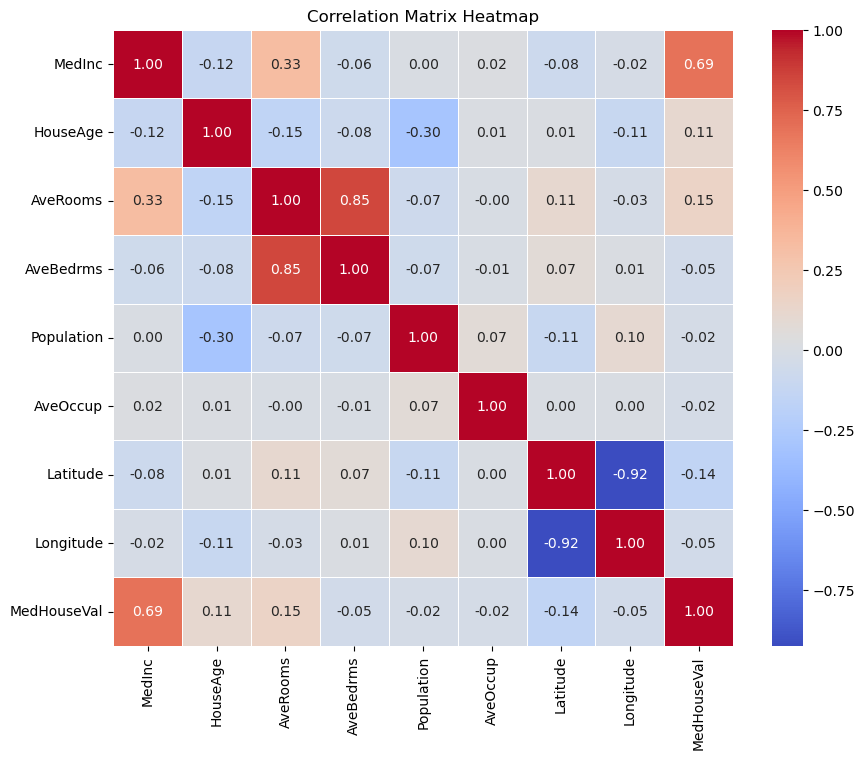

In [38]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    splitter='best',
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=2    
)

dt_reg.fit(X_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [42]:
y_pred = dt_reg.predict(X_test_scaled)

In [43]:
print("Decision Tree Perfomance")
print(f"MAE : {mean_absolute_error(y_test,y_pred)}")
print(f"MSE : {mean_squared_error(y_test,y_pred)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test,y_pred))}")
print(f"R2 Score : {r2_score(y_test,y_pred)}")

Decision Tree Perfomance
MAE : 0.49256708293183643
MSE : 0.4816287925742836
RMSE : 0.6939948073107489
R2 Score : 0.6424498354725977


In [44]:
for feature,val in zip(housing.feature_names,dt_reg.feature_importances_):
    print(f'{feature} : {val:.4f}')

MedInc : 0.7216
HouseAge : 0.0427
AveRooms : 0.0307
AveBedrms : 0.0010
Population : 0.0065
AveOccup : 0.1406
Latitude : 0.0378
Longitude : 0.0191


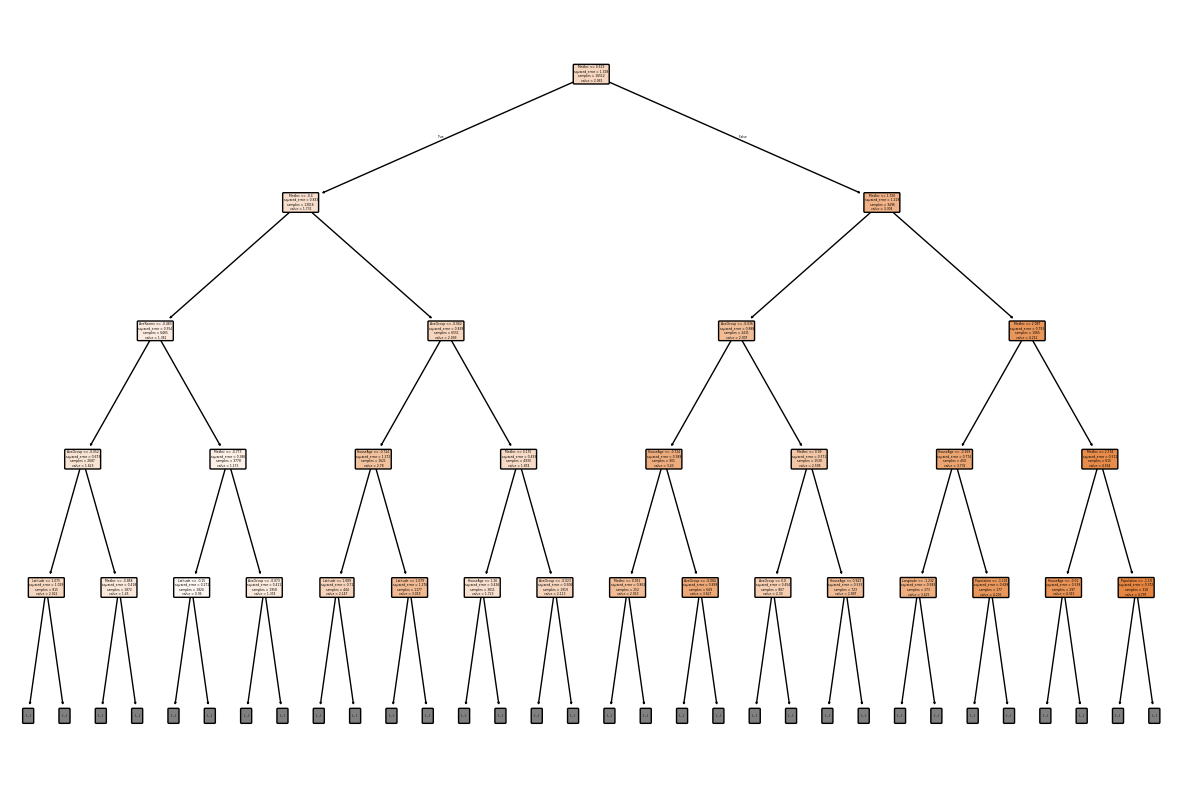

In [45]:
plt.figure(figsize=(15,10))
plot_tree(dt_reg,feature_names=housing.feature_names,
        rounded=True,filled=True,max_depth=4)
plt.show()

In [46]:
joblib.dump(dt_reg,"decision_tree_regression_model.pkl")
print("Model Saved !")

Model Saved !


In [47]:
loaded_dt = joblib.load("decision_tree_regression_model.pkl")

In [48]:
def predict_house_value(sample)->float:
    sample = scaler.transform(sample)
    prediction = loaded_dt.predict(sample)[0]
    return float(prediction)

In [49]:
test = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=housing.feature_names)

In [50]:
print(f"Predicted House Price : {predict_house_value(test):.4f}")

Predicted House Price : 4.6021


In [51]:
rf_base = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42
)

In [52]:
rf_base.fit(X_train_scaled,y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [53]:
y_pred_rf = rf_base.predict(X_test_scaled)

In [54]:
print("Random Forest Perfomance")
print(f"MAE : {mean_absolute_error(y_test,y_pred_rf)}")
print(f"MSE : {mean_squared_error(y_test,y_pred_rf)}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test,y_pred_rf))}")
print(f"R2 Score : {r2_score(y_test,y_pred_rf)}")

Random Forest Perfomance
MAE : 0.38528029581082945
MSE : 0.3053517119941828
RMSE : 0.5525863841918138
R2 Score : 0.7733138953784517


In [66]:
for feature,imp in zip(housing.feature_names,rf_base.feature_importances_):
    print(f"{feature} : {imp:.4f}")

MedInc : 0.4113
HouseAge : 0.0484
AveRooms : 0.1239
AveBedrms : 0.0272
Population : 0.0178
AveOccup : 0.1177
Latitude : 0.1299
Longitude : 0.1238


In [55]:
joblib.dump(rf_base,"random_forest_regessor.pkl")
print("Random Forest Model Saved !")

Random Forest Model Saved !


In [59]:
loaded_rf = joblib.load("random_forest_regessor.pkl")

In [62]:
def predict_house_value_rf(sample)->float:
    sample = scaler.transform(sample)
    prediction = loaded_rf.predict(sample)[0]
    return float(prediction)

In [63]:
test = pd.DataFrame([[8.3, 29, 6.5, 1.0, 400, 3.5, 34.2, -118.4]], columns=housing.feature_names)

In [65]:
print(f"Predicted House Price : {predict_house_value_rf(test):.4f}")

Predicted House Price : 3.9748
